In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# Data paths
TRAIN_PATH = "../data/raw/train.csv"

# Load the data
df_train = pd.read_csv(TRAIN_PATH)

# Column groups — defined once, reused across all analyses below
TARGET = "Churn"
ID_COL = "CustomerID"

numeric_cols = [
    "AccountAge", "MonthlyCharges", "TotalCharges", "ViewingHoursPerWeek",
    "AverageViewingDuration", "ContentDownloadsPerMonth", "UserRating",
    "SupportTicketsPerMonth", "WatchlistSize"
]

categorical_cols = [
    "SubscriptionType", "PaymentMethod", "PaperlessBilling", "ContentType",
    "MultiDeviceAccess", "DeviceRegistered", "GenrePreference", "Gender",
    "ParentalControl", "SubtitlesEnabled"
]

In [22]:
# For every categorical variable, compute the churn rate per category.
# This is more informative than a raw count plot: it directly answers
# "which category is riskiest?" rather than just "which is most common?"

churn_by_category = {}

for col in categorical_cols:
    rate = df_train.groupby(col)[TARGET].mean().sort_values(ascending=False) * 100
    churn_by_category[col] = rate
    print(f"\n=== Churn rate (%) by {col} ===")
    print(rate.round(2))


=== Churn rate (%) by SubscriptionType ===
SubscriptionType
Basic       19.65
Standard    18.43
Premium     16.28
Name: Churn, dtype: float64

=== Churn rate (%) by PaymentMethod ===
PaymentMethod
Electronic check    19.25
Mailed check        19.09
Bank transfer       17.93
Credit card         16.23
Name: Churn, dtype: float64

=== Churn rate (%) by PaperlessBilling ===
PaperlessBilling
No     18.16
Yes    18.09
Name: Churn, dtype: float64

=== Churn rate (%) by ContentType ===
ContentType
Both        18.85
Movies      17.78
TV Shows    17.74
Name: Churn, dtype: float64

=== Churn rate (%) by MultiDeviceAccess ===
MultiDeviceAccess
No     18.17
Yes    18.07
Name: Churn, dtype: float64

=== Churn rate (%) by DeviceRegistered ===
DeviceRegistered
Mobile      18.24
Tablet      18.21
Computer    18.13
TV          17.90
Name: Churn, dtype: float64

=== Churn rate (%) by GenrePreference ===
GenrePreference
Comedy     19.34
Sci-Fi     19.14
Drama      17.87
Fantasy    17.67
Action     16.59


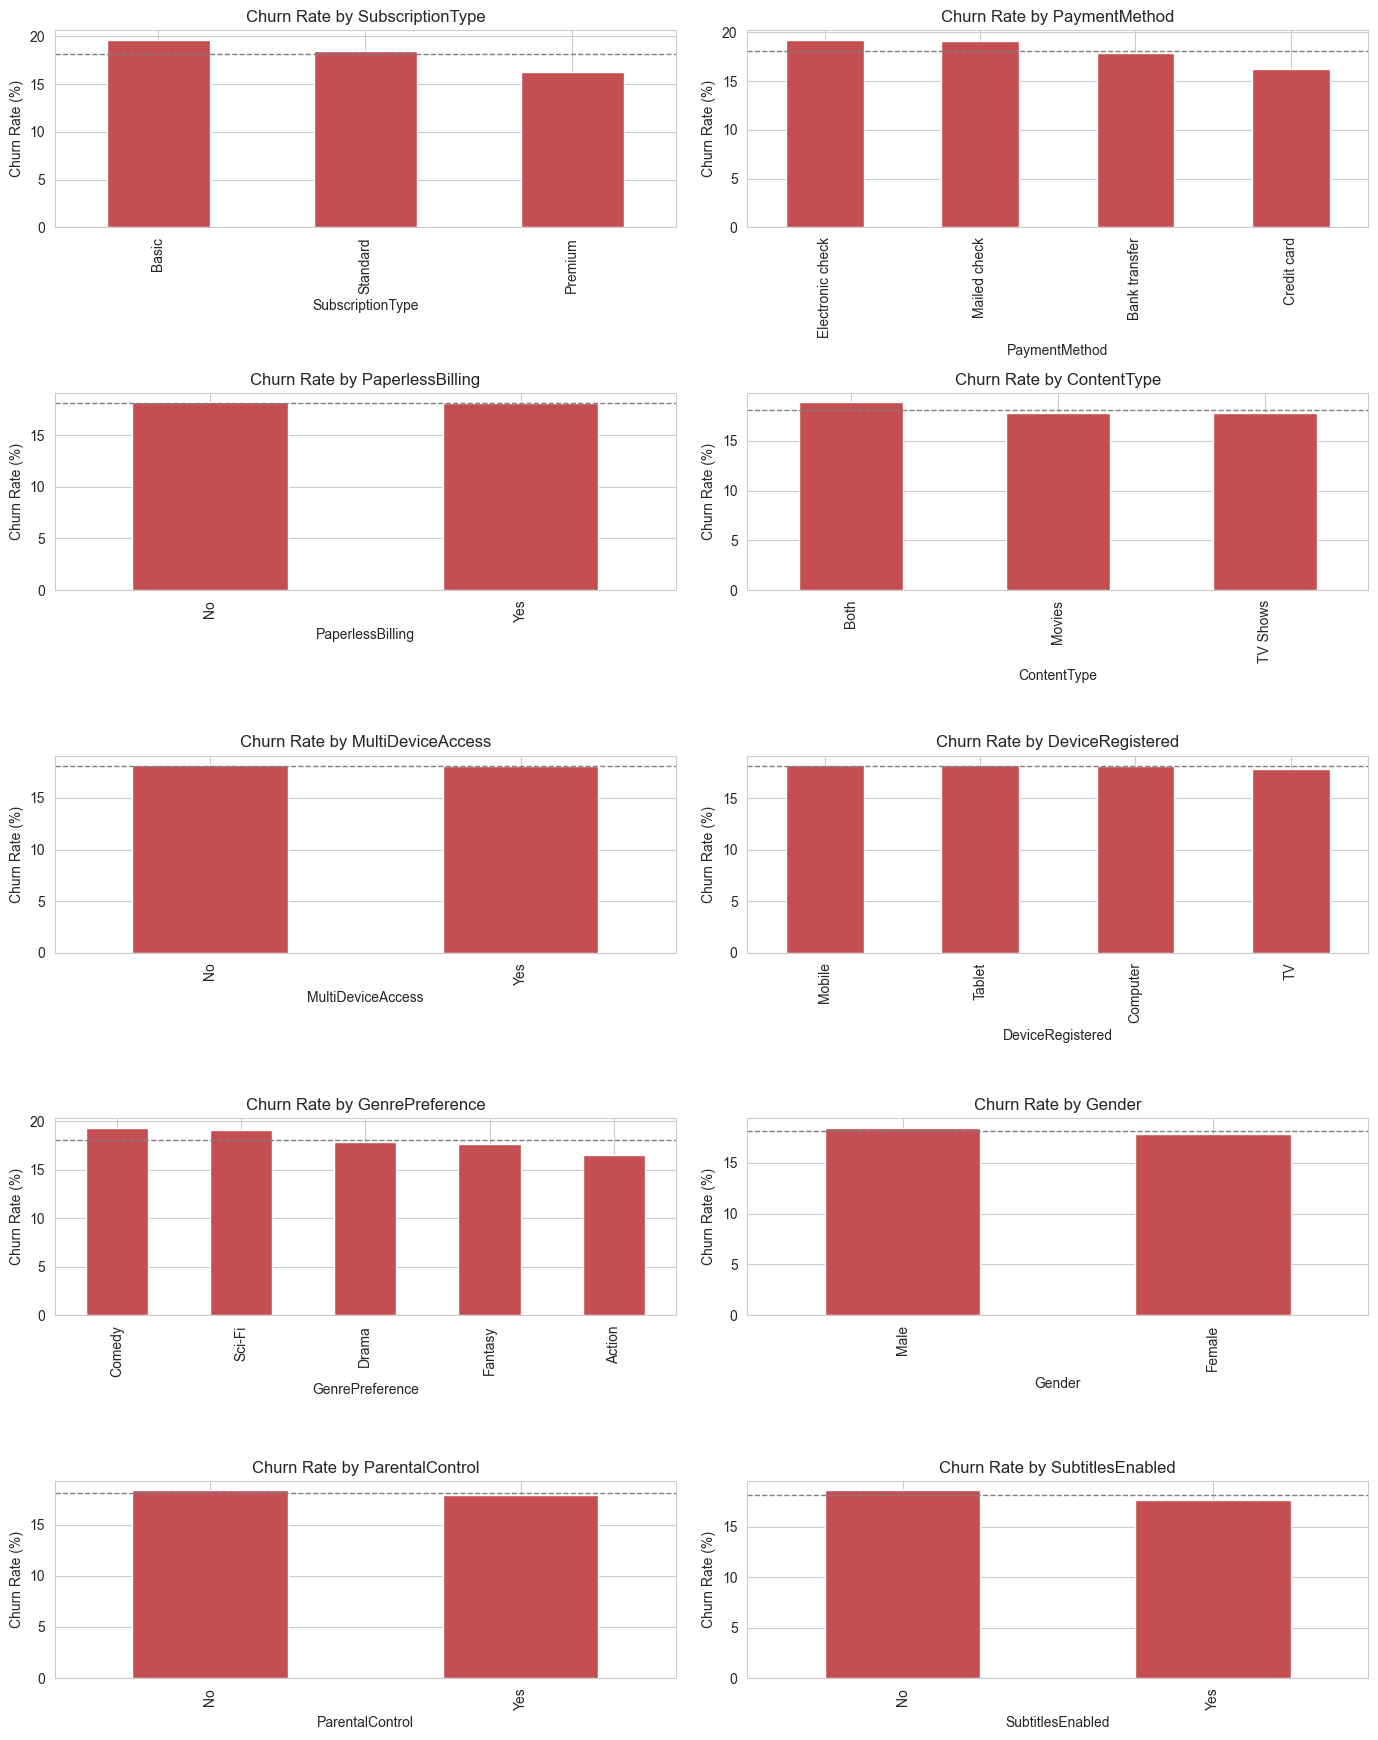

In [23]:
# Visualize all categorical variables in a grid — fast way to scan
# for the strongest business drivers in one pass.
n_cols = 2
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    churn_by_category[col].plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.axhline(df_train[TARGET].mean() * 100, color="gray", linestyle="--", linewidth=1)
    # The dashed line marks the overall churn rate (~18%) as a reference baseline —
    # bars above it flag higher-than-average risk categories.

# Hide unused subplots if the grid isn't fully filled
for ax in axes[len(categorical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/churn_by_categorical.png", dpi=150)
plt.show()

## Churn Rate by Categorical Variables (Visual Overview)

The dashed line in each plot marks the overall churn rate baseline (~18%).
Bars above the line indicate above-average risk categories; bars below
indicate below-average risk.

**Key observations:**

- **SubscriptionType**: churn decreases as plan tier increases —
  Basic (~19.5%) > Standard (~18.3%) > Premium (~16.2%). Premium
  subscribers are the most loyal segment, likely reflecting either
  higher price commitment or higher perceived value from the service.
- **PaymentMethod**: Electronic check and Mailed check show the highest
  churn (~19%), while Credit card is the lowest (~16%). This mirrors a
  pattern well known in subscription businesses: automated, "invisible"
  payment methods (credit card) tend to retain customers longer than
  manual payment methods, which create more friction and more
  opportunities to actively cancel.
- **GenrePreference**: Comedy and Sci-Fi viewers churn slightly more
  (~19%) than Action viewers (~16.5%). The spread across genres is
  modest but consistent.
- **ContentType, DeviceRegistered, Gender, ParentalControl,
  SubtitlesEnabled**: all show only small deviations from the baseline
  (within 1-2 percentage points). Visually, these variables look close
  to "flat" — i.e., not strong standalone churn drivers.
- **PaperlessBilling and MultiDeviceAccess**: bars are visually
  indistinguishable from the baseline in both categories — these appear
  to have virtually no relationship with churn on their own.

**Important caveat**: at this stage, differences are read *visually*.
Given the large sample size (243,787 rows), even a small visual gap can
still be statistically significant — and conversely, a category with a
visible gap might not be reliable if driven by a small subgroup. The
Chi-square test (see companion analysis) is needed to confirm which of
these visual patterns are statistically real versus noise.

In [24]:
# A visual difference in churn rate isn't necessarily statistically significant.
# Chi-square tests whether the relationship between each categorical variable
# and churn is unlikely to be due to random chance (p < 0.05 = significant).

chi2_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df_train[col], df_train[TARGET])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    chi2_results.append({"feature": col, "chi2_stat": chi2, "p_value": p_value})

chi2_df = pd.DataFrame(chi2_results).sort_values("chi2_stat", ascending=False)
chi2_df["significant_at_0.05"] = chi2_df["p_value"] < 0.05
chi2_df

,feature,chi2_stat,p_value,significant_at_0.05
0,SubscriptionType,318.449356,7.072956e-70,True
1,PaymentMethod,239.863822,1.018485e-51,True
6,GenrePreference,169.296653,1.480532e-35,True
3,ContentType,43.453997,3.665087e-10,True
9,SubtitlesEnabled,37.251633,1.038280e-09,True
7,Gender,13.554239,2.317674e-04,True
8,ParentalControl,7.429245,6.417227e-03,True
5,DeviceRegistered,2.839135,4.170980e-01,False
4,MultiDeviceAccess,0.396155,5.290818e-01,False
2,PaperlessBilling,0.202776,6.524893e-01,False


## Statistical Significance of Categorical Variables (Chi-square Test)

| Feature | Chi2 Stat | p-value | Significant (α=0.05) |
|---|---|---|---|
| SubscriptionType | 318.45 | 7.07e-70 | Yes |
| PaymentMethod | 239.86 | 1.02e-51 | Yes |
| GenrePreference | 169.30 | 1.48e-35 | Yes |
| ContentType | 43.45 | 3.67e-10 | Yes |
| SubtitlesEnabled | 37.25 | 1.04e-09 | Yes |
| Gender | 13.55 | 2.32e-04 | Yes |
| ParentalControl | 7.43 | 6.42e-03 | Yes |
| DeviceRegistered | 2.84 | 0.417 | No |
| MultiDeviceAccess | 0.40 | 0.529 | No |
| PaperlessBilling | 0.20 | 0.652 | No |

**Interpretation:**

- **7 out of 10** categorical features show a statistically significant
  association with churn. Ranked by Chi2 statistic (strength of
  association), the top three are **SubscriptionType**, **PaymentMethod**,
  and **GenrePreference** — consistent with what the visual analysis
  already suggested as the most differentiated bars.
- **DeviceRegistered, MultiDeviceAccess, and PaperlessBilling are NOT
  statistically significant** (p-values 0.42, 0.53, 0.65 — all far above
  0.05). This confirms the "flat bars" observed visually for
  `PaperlessBilling` and `MultiDeviceAccess`: these variables carry no
  reliable relationship with churn in this dataset and are strong
  candidates for exclusion during feature selection, unless a business
  reason argues otherwise.
- **Important nuance on `Gender` and `ParentalControl`**: both are
  flagged as statistically significant (p < 0.05), but their Chi2
  statistics are the lowest among the significant group (13.55 and 7.43),
  and their visual churn-rate gaps were small (~1 point). With a sample
  size this large (243,787 rows), the Chi-square test can detect very
  small, practically negligible effects as "significant." **Statistical
  significance here should not be read as strong business relevance** —
  these two variables are technically associated with churn but are
  unlikely to be useful, high-impact predictors on their own.
- **Practical implication for Feature Engineering (Step 5)**: prioritize
  `SubscriptionType`, `PaymentMethod`, and `GenrePreference` as primary
  categorical drivers, keep `ContentType` and `SubtitlesEnabled` as
  secondary features, and treat `Gender`/`ParentalControl` as low-priority
  (statistically valid but practically weak). Consider dropping
  `DeviceRegistered`, `MultiDeviceAccess`, and `PaperlessBilling`
  entirely, or keeping them only if a later feature-importance analysis
  (Step 6/7) shows otherwise.
- **Recommended follow-up**: for the significant features, compute
  **Cramér's V** (effect size for categorical association) alongside the
  Chi2 test in the next iteration — it normalizes for sample size and
  gives a 0-1 scale of *how strong* the association actually is, which
  is more actionable than the p-value alone.

C:\Users\houss\AppData\Local\Temp\ipykernel_24592\3487229330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E52"])
C:\Users\houss\AppData\Local\Temp\ipykernel_24592\3487229330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E52"])
C:\Users\houss\AppData\Local\Temp\ipykernel_24592\3487229330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E5

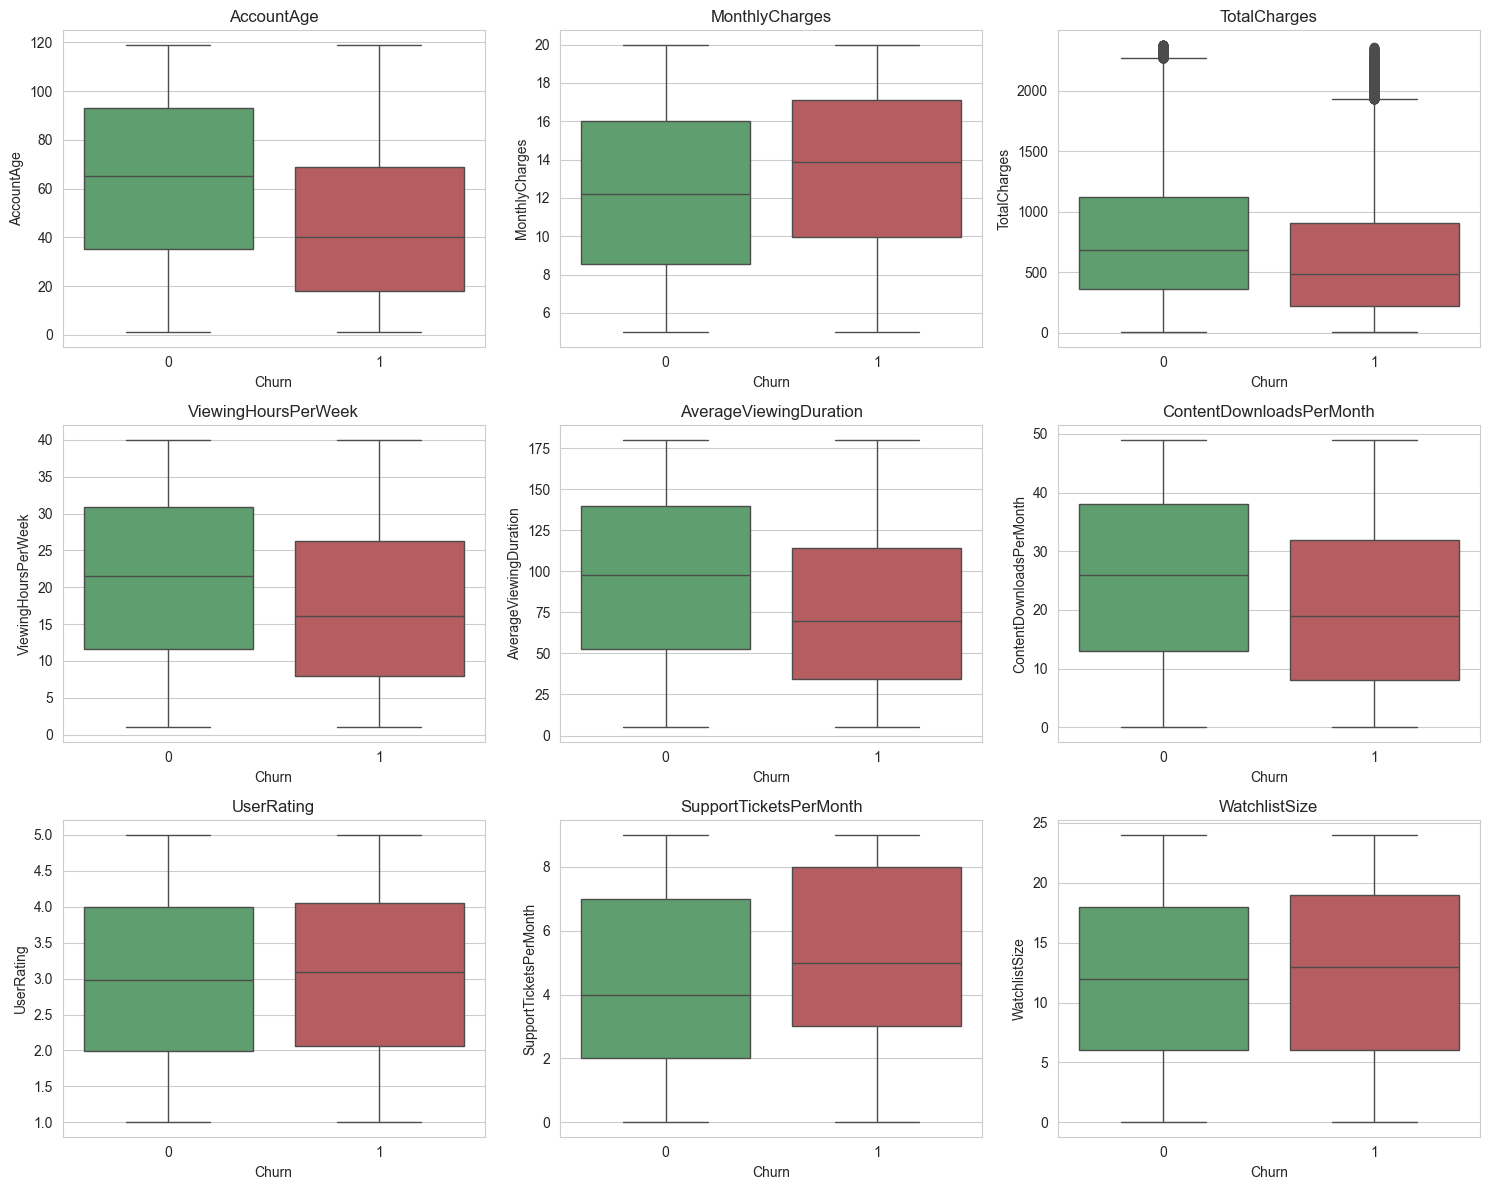

In [25]:
# Boxplots: compare the spread and median of each numeric variable
# across churned vs retained customers in a single grid.

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_train, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E52"])
    ax.set_title(col)
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.savefig("../reports/figures/numeric_boxplots_by_churn.png", dpi=150)
plt.show()

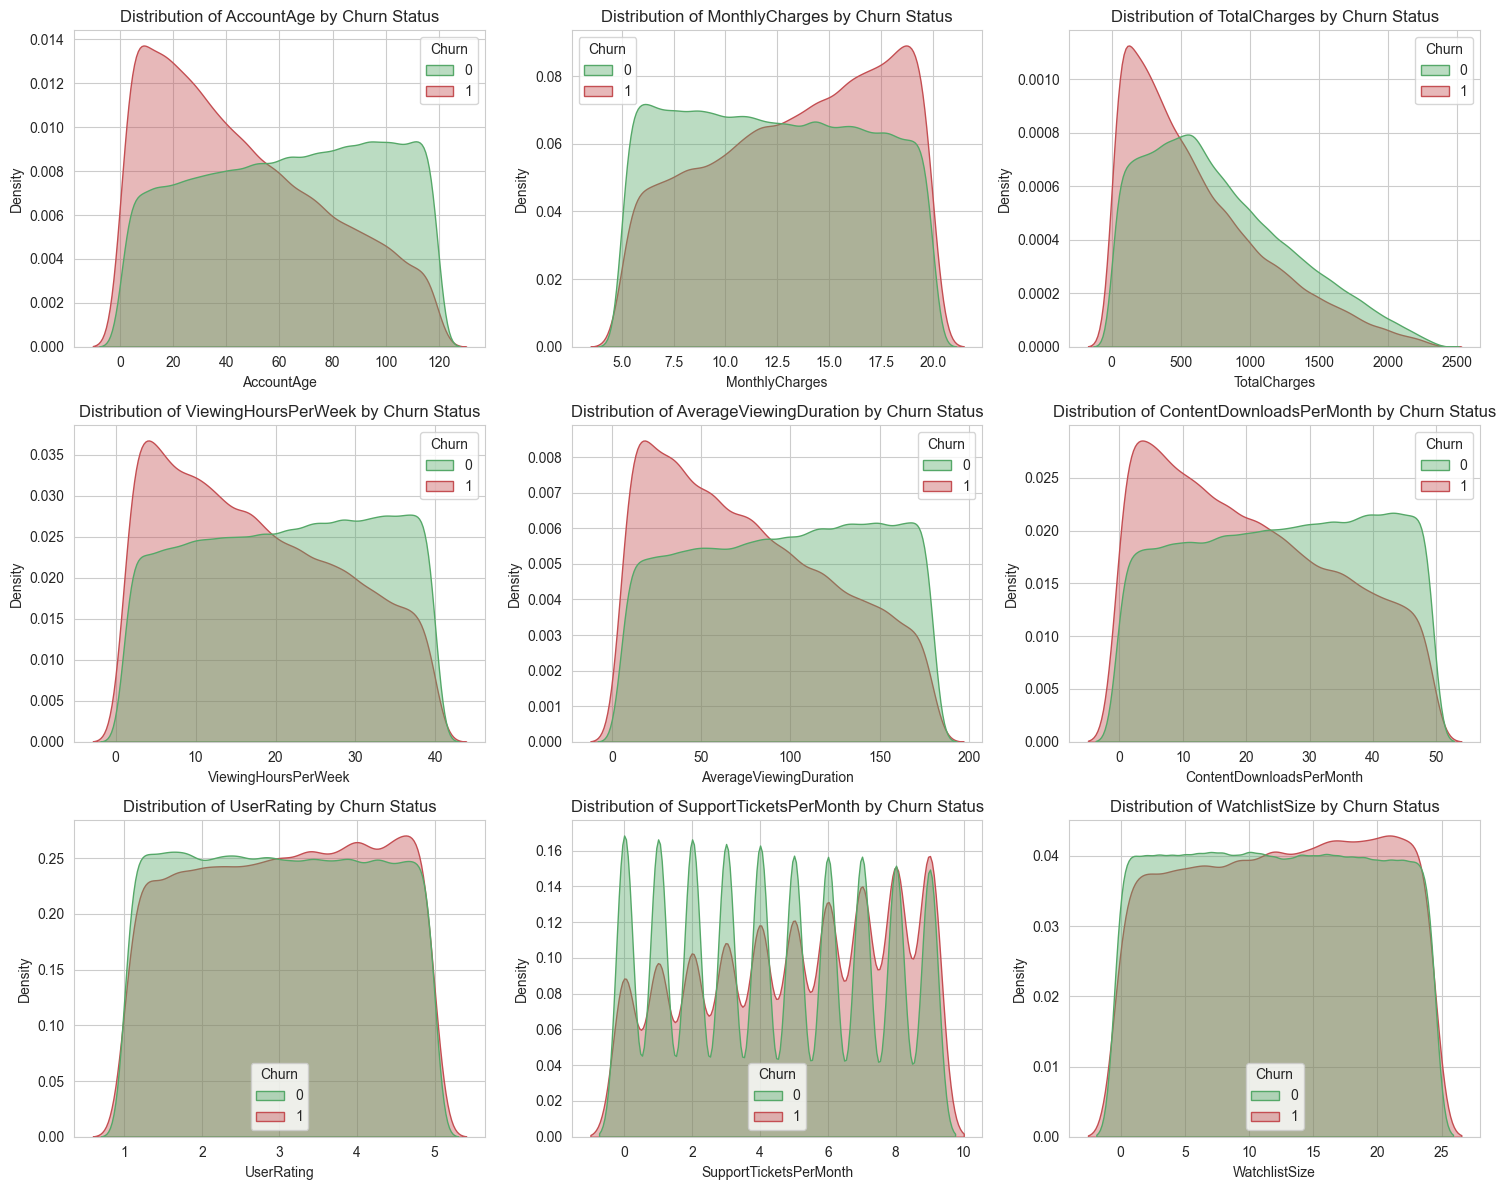

In [ ]:
# KDE plots give a sharper view than boxplots for variables where the
# SHAPE of the distribution (not just the median) differs between groups —


fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df_train, x=col, hue=TARGET, fill=True, common_norm=False,
                palette=["#55A868", "#C44E52"], alpha=0.4, ax=ax)
    ax.set_title(f"Distribution of {col} by Churn Status")

plt.tight_layout()
plt.savefig("../reports/figures/numeric_kde_by_churn.png", dpi=150)
plt.show()

In [27]:
# Independent t-test: checks whether the mean of each numeric variable
# is significantly different between churned and retained customers.
# Complements the visual boxplots/KDEs with a formal significance check.

ttest_results = []

for col in numeric_cols:
    churned = df_train.loc[df_train[TARGET] == 1, col].dropna()
    retained = df_train.loc[df_train[TARGET] == 0, col].dropna()
    t_stat, p_value = stats.ttest_ind(churned, retained, equal_var=False)

    ttest_results.append({
        "feature": col,
        "mean_churned": churned.mean(),
        "mean_retained": retained.mean(),
        "t_stat": t_stat,
        "p_value": p_value,
    })

ttest_df = pd.DataFrame(ttest_results).sort_values("p_value")
ttest_df["significant_at_0.05"] = ttest_df["p_value"] < 0.05
ttest_df

,feature,mean_churned,mean_retained,t_stat,p_value,significant_at_0.05
0,AccountAge,45.674121,63.273290,-103.427301,0.000000e+00,True
1,MonthlyCharges,13.414880,12.286129,50.355054,0.000000e+00,True
2,TotalCharges,616.737816,780.402245,-62.070789,0.000000e+00,True
3,ViewingHoursPerWeek,17.427741,21.182697,-65.038906,0.000000e+00,True
4,AverageViewingDuration,76.494840,95.754533,-75.063229,0.000000e+00,True
5,ContentDownloadsPerMonth,20.526323,25.383853,-65.573769,0.000000e+00,True
7,SupportTicketsPerMonth,5.017451,4.390576,41.852510,0.000000e+00,True
6,UserRating,3.057037,2.990688,10.940080,7.838057e-28,True
8,WatchlistSize,12.350867,11.944941,10.765998,5.248765e-27,True


## Statistical Significance of Numeric Variables (t-test)

| Feature | Mean (Churned) | Mean (Retained) | t-stat | p-value | Significant |
|---|---|---|---|---|---|
| AccountAge | 45.67 | 63.27 | -103.43 | ~0 | Yes |
| MonthlyCharges | 13.41 | 12.29 | 50.36 | ~0 | Yes |
| TotalCharges | 616.74 | 780.40 | -62.07 | ~0 | Yes |
| ViewingHoursPerWeek | 17.43 | 21.18 | -65.04 | ~0 | Yes |
| AverageViewingDuration | 76.49 | 95.75 | -75.06 | ~0 | Yes |
| ContentDownloadsPerMonth | 20.53 | 25.38 | -65.57 | ~0 | Yes |
| SupportTicketsPerMonth | 5.02 | 4.39 | 41.85 | ~0 | Yes |
| UserRating | 3.06 | 2.99 | 10.94 | 7.84e-28 | Yes |
| WatchlistSize | 12.35 | 11.94 | 10.77 | 5.25e-27 | Yes |

**Interpretation:**

- **All 9 numeric features are statistically significant** at p < 0.05 —
  including several with p-values effectively at 0. With a sample size of
  243,787 rows, this is expected: at this scale, even very small mean
  differences become statistically detectable. **The t-stat magnitude
  (not just significance) should be used to rank practical importance.**
- **Strongest effects, ranked by |t-stat|**: `AccountAge` (-103.4),
  `AverageViewingDuration` (-75.1), `ContentDownloadsPerMonth` (-65.6),
  `ViewingHoursPerWeek` (-65.0), `TotalCharges` (-62.1). This ranking
  matches closely with the correlation analysis — reinforcing that
  **tenure and engagement are the dominant churn drivers** in this dataset.
- **Weakest (though still "significant") effects**: `UserRating` (10.94)
  and `WatchlistSize` (10.77) — an order of magnitude smaller than the top
  drivers, and consistent with their near-zero correlation coefficients
  (0.02) seen in the correlation matrix. These should be treated as
  low-priority features despite technical significance.
- **Notable and slightly counter-intuitive pattern — `UserRating`**:
  churned customers have a marginally **higher** average rating (3.06)
  than retained customers (2.99). While statistically significant, the
  gap is very small (0.07 points on a 1-5 scale) and the correlation with
  churn is negligible (0.02). This is likely **not a meaningful business
  signal** — a customer can rate the service positively and still churn
  for unrelated reasons (price, life circumstances, competing
  services) — and should not be over-interpreted as "satisfied customers
  churn more."
- **`MonthlyCharges` and `SupportTicketsPerMonth` are higher in churned
  customers** — consistent with the correlation analysis: churners tend
  to be on higher-cost plans and generate more support friction, both
  actionable business signals for a retention strategy (e.g. proactive
  outreach for high-ticket-volume customers on premium-priced plans).

**Conclusion**: the t-test results confirm and quantify what the
correlation matrix already suggested — **tenure (`AccountAge`) and
engagement metrics are the dominant churn drivers**, `MonthlyCharges`
and `SupportTicketsPerMonth` are secondary but actionable signals, and
`UserRating`/`WatchlistSize` are statistically detectable but practically
weak. This ranking will directly inform feature prioritization in Step 5
(Feature Engineering) and provides a baseline expectation for feature
importance rankings in Step 6 (Modeling).

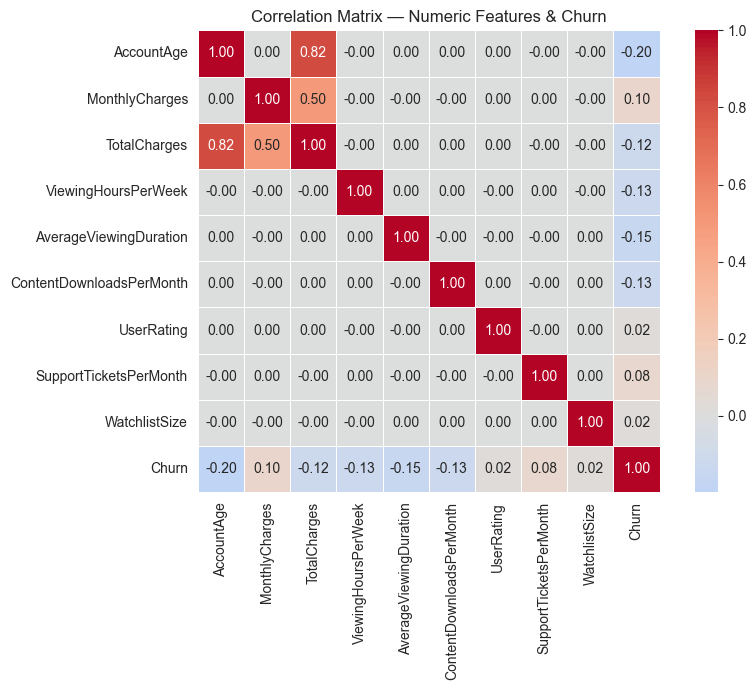

AccountAge                 -0.197736
AverageViewingDuration     -0.146897
ContentDownloadsPerMonth   -0.129752
ViewingHoursPerWeek        -0.128645
TotalCharges               -0.120529
MonthlyCharges              0.100473
SupportTicketsPerMonth      0.084064
UserRating                  0.022124
WatchlistSize               0.021739
Name: Churn, dtype: float64

In [28]:
# Full correlation matrix — confirms the AccountAge/TotalCharges relationship
# flagged in Step 1, and checks for any other pairs worth addressing
# before modeling (multicollinearity risk for linear models).

corr_matrix = df_train[numeric_cols + [TARGET]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features & Churn")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png", dpi=150)
plt.show()

# Correlation of each numeric feature with the target specifically —
# quick ranked view of which numeric variables move together with churn.
corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

## Correlation Matrix — Numeric Features & Churn

**Inter-feature correlations (multicollinearity check):**

- `AccountAge` and `TotalCharges` are strongly correlated (**0.82**) —
  confirms the alert already flagged in Step 1 (data profiling). This is
  expected: longer-tenured customers accumulate more total billing over
  time. For linear models (e.g. Logistic Regression), this pair should be
  handled carefully — either drop one, or replace both with a derived
  ratio feature (e.g. `TotalCharges / AccountAge`, effectively an average
  historical monthly spend) to remove the redundancy while keeping the
  signal.
- `MonthlyCharges` and `TotalCharges` show a moderate correlation (**0.50**)
  — logical, since total billing partly reflects the monthly rate, but
  weak enough that both can coexist without a strong multicollinearity risk.
- All other numeric feature pairs show **near-zero correlation** (-0.00 to
  0.00) — the numeric features are largely independent of each other,
  which is good news for tree-based models and reduces redundancy concerns
  overall.

**Correlation with Churn (ranked by absolute strength):**

| Feature | Correlation with Churn | Direction |
|---|---|---|
| AccountAge | -0.20 | Longer tenure → less churn |
| AverageViewingDuration | -0.15 | Longer sessions → less churn |
| ViewingHoursPerWeek | -0.13 | More weekly usage → less churn |
| ContentDownloadsPerMonth | -0.13 | More downloads → less churn |
| TotalCharges | -0.12 | Higher cumulative spend → less churn (tenure-driven) |
| MonthlyCharges | +0.10 | Higher monthly rate → more churn |
| SupportTicketsPerMonth | +0.08 | More tickets → more churn |
| UserRating | +0.02 | Negligible |
| WatchlistSize | +0.02 | Negligible |

**Interpretation:**

- **`AccountAge` is the single strongest linear driver of churn** among
  numeric features, confirming the cohort pattern expected from Step 1:
  newer customers are meaningfully more likely to churn than long-tenured
  ones.
- The three engagement metrics (`AverageViewingDuration`,
  `ViewingHoursPerWeek`, `ContentDownloadsPerMonth`) all move together in
  the same direction and at similar strength (-0.13 to -0.15) — this is a
  consistent, coherent engagement signal, not a coincidence on one metric.
  Good candidates to combine into a single composite "engagement score" in
  Feature Engineering (Step 5).
- `MonthlyCharges` is **positively** correlated with churn while
  `TotalCharges` is **negatively** correlated — this is not contradictory:
  it suggests customers who churn tend to be on higher-priced plans but
  with **shorter tenure** (consistent with the low `AccountAge`), so they
  haven't yet accumulated high `TotalCharges`. This points to a
  **price-sensitivity-at-onboarding** pattern rather than long-term
  value customers leaving.
- `UserRating` and `WatchlistSize` show **essentially no linear
  relationship** with churn (0.02) — despite `UserRating` appearing
  statistically significant in the t-test (see companion analysis), its
  practical/linear association with churn is negligible.

**Important caveat**: this matrix only captures *linear* relationships
(Pearson correlation). A near-zero value doesn't rule out a non-linear
or threshold-based relationship — this will be re-assessed via feature
importance and SHAP in the modeling stage (Steps 6-7).

C:\Users\houss\AppData\Local\Temp\ipykernel_24592\835347456.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df_train.groupby("tenure_bucket")[TARGET].agg(["mean", "count"])


               churn_rate_%  n_customers
tenure_bucket                           
0-6m                  32.40        12080
6-12m                 29.91        12049
1-2y                  28.25        24657
2-3y                  24.70        24773
3-5y                  19.73        49083
5y+                   11.47       121145


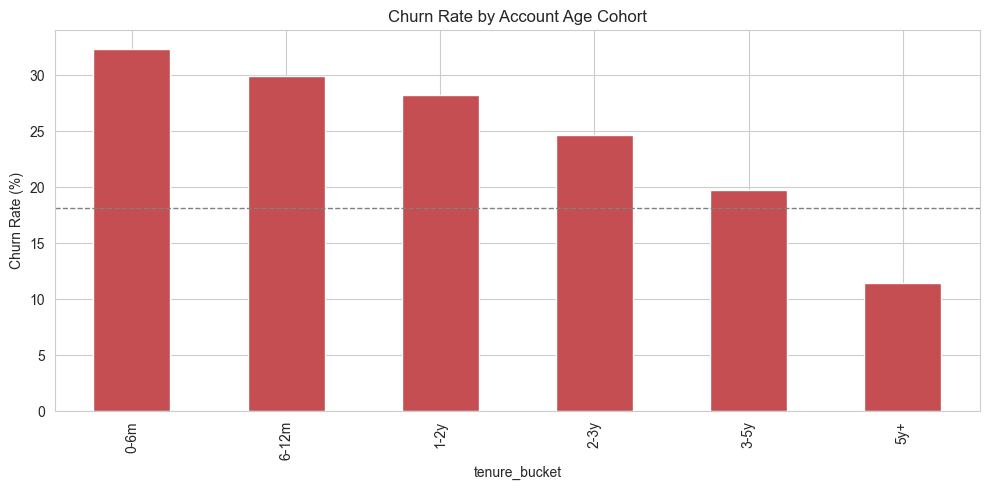

In [29]:
# Churn risk is rarely linear over customer lifetime — bucketing tenure
# often reveals an "early churn" pattern (onboarding failure) vs
# "late churn" pattern (fatigue/competition), which require different
# retention strategies.

df_train["tenure_bucket"] = pd.cut(
    df_train["AccountAge"],
    bins=[0, 6, 12, 24, 36, 60, 200],
    labels=["0-6m", "6-12m", "1-2y", "2-3y", "3-5y", "5y+"]
)

tenure_churn = df_train.groupby("tenure_bucket")[TARGET].agg(["mean", "count"])
tenure_churn["mean"] = (tenure_churn["mean"] * 100).round(2)
tenure_churn.columns = ["churn_rate_%", "n_customers"]
print(tenure_churn)

fig, ax1 = plt.subplots(figsize=(10, 5))
tenure_churn["churn_rate_%"].plot(kind="bar", ax=ax1, color="#C44E52")
ax1.set_ylabel("Churn Rate (%)")
ax1.axhline(df_train[TARGET].mean() * 100, color="gray", linestyle="--", linewidth=1)
plt.title("Churn Rate by Account Age Cohort")
plt.tight_layout()
plt.savefig("../reports/figures/churn_by_tenure_cohort.png", dpi=150)
plt.show()

## Churn Rate by Account Age Cohort

| Cohort | Churn Rate (%) | vs Baseline (~18%) |
|---|---|---|
| 0-6m | ~32.3% | +14.3 pts |
| 6-12m | ~29.9% | +11.9 pts |
| 1-2y | ~28.2% | +10.2 pts |
| 2-3y | ~24.6% | +6.6 pts |
| 3-5y | ~19.6% | +1.6 pts |
| 5y+ | ~11.4% | -6.6 pts |

**Interpretation:**

- The relationship between tenure and churn is **clearly monotonic and
  strong**: churn risk decreases steadily and consistently as account age
  increases, from ~32% in the first 6 months down to ~11% after 5 years —
  nearly a **3x difference** between the riskiest and safest cohorts.
- This directly confirms and visually quantifies the correlation already
  found in the numeric analysis (`AccountAge` had the strongest
  correlation with churn, -0.20, and the highest t-stat, -103.4).
- **Every cohort under 3 years sits above the overall baseline churn
  rate**, meaning the "average" 18% churn figure masks a much sharper
  reality for newer customers: roughly **1 in 3 customers churn within
  their first 6 months**.
- This is a classic **early-lifecycle / onboarding churn pattern**, not a
  long-term fatigue pattern. It points to a specific business
  intervention: retention efforts (and modeling risk scores) should be
  weighted most heavily toward the first 12-24 months of the customer
  relationship, where the vast majority of preventable churn is
  concentrated.
- For **Feature Engineering (Step 5)**, `tenure_bucket` (or a binary
  `is_early_lifecycle` flag for accounts under 6-12 months) is a strong
  candidate feature — the relationship is non-linear enough that a
  bucketed/flagged version may add value on top of the raw `AccountAge`
  numeric value, especially for models sensitive to non-linearity like
  Logistic Regression.

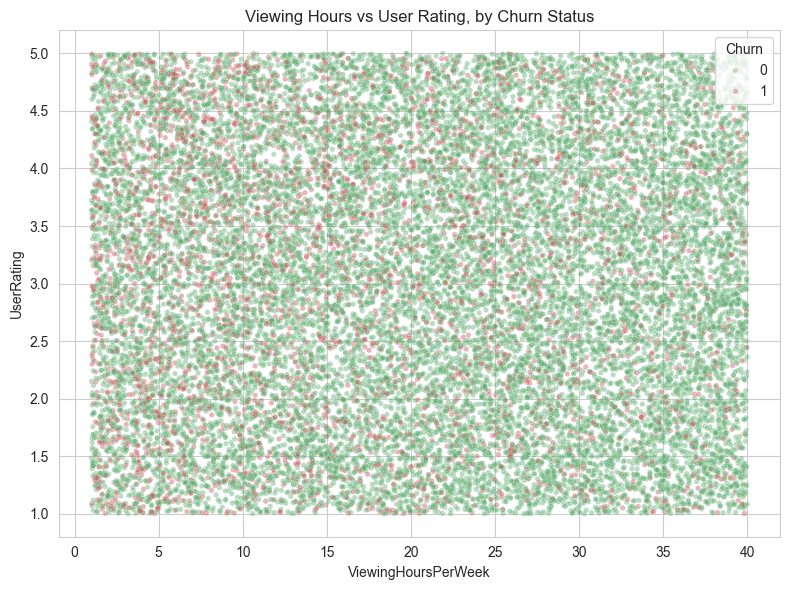

In [30]:
# Combine two behavioral signals (usage volume + satisfaction) into a
# single scatter, colored by churn — checks whether churners cluster
# in a specific low-engagement / low-rating region rather than
# just on one dimension at a time.

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train.sample(min(20000, len(df_train)), random_state=42),  # sample for readability
    x="ViewingHoursPerWeek", y="UserRating", hue=TARGET,
    palette=["#55A868", "#C44E52"], alpha=0.4, s=15
)
plt.title("Viewing Hours vs User Rating, by Churn Status")
plt.tight_layout()
plt.savefig("../reports/figures/engagement_scatter.png", dpi=150)
plt.show()

## Viewing Hours vs User Rating, by Churn Status (Bivariate Scatter)

**Interpretation:**

- Unlike the tenure cohort analysis, this scatter plot shows **no visible
  clustering or separation** between churned (red) and retained (green)
  customers across the `ViewingHoursPerWeek` x `UserRating` space. Red
  points are scattered essentially uniformly across the entire plot, with
  no visible concentration in any particular region (e.g. no dense red
  cluster in the low-hours/low-rating corner, which would have been the
  intuitively expected "at-risk" zone).
- This is **consistent with, not contradictory to**, the earlier
  correlation findings: `ViewingHoursPerWeek` (-0.13) and `UserRating`
  (0.02) both have weak-to-negligible linear correlation with churn
  individually, and this 2D view confirms that **combining them doesn't
  reveal a visible interaction effect either** — at least not one
  detectable by eye at this scale and overplotting level.
- Both axes also show a distribution close to uniform (viewing hours
  spread evenly from 0 to 40, ratings spread evenly from 1 to 5), which
  reinforces the earlier hypothesis from Step 1 that this dataset may be
  **synthetically generated** rather than reflecting organic real-world
  usage patterns (real engagement data is rarely this uniformly
  distributed).
- **Practical conclusion**: this pair of variables, together, is **not a
  useful 2D segmentation view** for identifying at-risk customers. It
  does not mean these variables are irrelevant to the model — tree-based
  models (Random Forest, XGBoost) can still exploit weak, non-linear, or
  higher-order interactions that aren't visible in a simple 2D scatter.
  This will be verified more rigorously through **feature importance and
  SHAP analysis in Step 6/7**, rather than through further manual
  bivariate/multivariate plotting, which has reached diminishing returns
  for this dataset's numeric-behavioral features.